<a href="https://colab.research.google.com/github/VishalMaurya15031/AI-Spend-Audit-web-app/blob/main/Growth_Accounting_Report_Vishal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xlrd -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Active Users (1).xls to Active Users (1).xls


In [4]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

df.head()

,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10,...,w51,w52,w53,w54,w55,w56,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59
0,fd7c28f9fd8045f2,fd7c28f9fd8045f2,fd7c28f9fd8045f2,fd7c28f9fd8045f2,fd7c28f9fd8045f2,231d91be38352d7a,306243851b716bf6,149f7dd1efe25ebc,191a909000d7123d,191a909000d7123d,...,ffedb2a5b3b4838,ffedb2a5b3b4838,ffedb2a5b3b4838,fffe76c3a948cdfb,fffe76c3a948cdfb,fffe76c3a948cdfb,NaN,NaN,NaN,2.0
1,673000000000000,5ff4cd01b5eae601,1402081a023d5c18,45b649baf6882a4a,c92f828ffdd1c1c0,7c8de50e4a84f1ee,eff8ecf5cb54ffe7,b50740442eb78a75,e85d8cc04adae6cc,cf8dfdbbb526c506,...,bc1a7fed50193f41,bb1e4d0008cbabf,bb2e76bb3174a0be,bd0228ee50f09d79,bb4370c7306bb336,b81f04d72ef2e150,NaN,NaN,NaN,2.0
2,15600000000000000000000,7cd4b3218dbffa0b,99acf0df83dc2831,49740201a5f203eb,8cf94ff315895955,58453f722733b72e,7ec2e98a1613db6c,20e2a9da9c0146ee,fbeb97ecc066639,42aabbe8fa2b258a,...,a7292f3d0d80985b,a5d5d8560d64b95a,a7914920e3ef2b55,a95f016d03945e5c,a6e99e4acd1701d6,a3c2066710a6d65,NaN,NaN,NaN,2.0
3,10156b703e26c334,25167a08527132ac,4820782b3cb8f570,ae16cc7b72fcee52,ecaa9c1913ef2f65,e02ecf94fd8ee5c8,1aba368c76311ef3,49b64be1edab128c,6dff050c07b69b4e,b6be357ac8671a1f,...,9eef01de4af7d619,9d6d4be4eab27e4b,a01148c9b12f3c15,a29b81926b57d967,9f5835c16ef759bb,9af6497cd753b9b9,NaN,NaN,NaN,2.0
4,103f96126c333035,7fbf03c17ea12589,d8aaa5b13424da35,bd26c51dd185a3cb,6028ea4b2b053007,b5c3d0e920ed6175,fa45dfe1357d3db9,b9928cbdfb35c1,d6a7f937733dea7,b7a452cfbee2d008,...,d7f6ec45f8815d98,d6ec98374c4a453,d7415d7979ce86d9,d84e5dc003ef9155,d851694a086bfc17,d63515fbe6484033,NaN,NaN,NaN,2.0


In [5]:
print(df.columns)

Index(['w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8', 'w9', 'w10', 'w11',
       'w12', 'w13', 'w14', 'w15', 'w16', 'w17', 'w18', 'w19', 'w20', 'w21',
       'w22', 'w23', 'w24', 'w25', 'w26', 'w27', 'w28', 'w29', 'w30', 'w31',
       'w32', 'w33', 'w34', 'w35', 'w36', 'w37', 'w38', 'w39', 'w40', 'w41',
       'w42', 'w43', 'w44', 'w45', 'w46', 'w47', 'w48', 'w49', 'w50', 'w51',
       'w52', 'w53', 'w54', 'w55', 'w56', 'Unnamed: 56', 'Unnamed: 57',
       'Unnamed: 58', 'Unnamed: 59'],
      dtype='object')


In [13]:
weeks = df.columns.tolist()

print(weeks)

['w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8', 'w9', 'w10', 'w11', 'w12', 'w13', 'w14', 'w15', 'w16', 'w17', 'w18', 'w19', 'w20', 'w21', 'w22', 'w23', 'w24', 'w25', 'w26', 'w27', 'w28', 'w29', 'w30', 'w31', 'w32', 'w33', 'w34', 'w35', 'w36', 'w37', 'w38', 'w39', 'w40', 'w41', 'w42', 'w43', 'w44', 'w45', 'w46', 'w47', 'w48', 'w49', 'w50', 'w51', 'w52', 'w53', 'w54', 'w55', 'w56', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59']


In [15]:
week_users = {}

for week in weeks:

    users = set(
        df[week]
        .dropna()
        .astype(str)
    )

    week_users[week] = users

In [16]:
results = []

all_previous_users = set()

for i, week in enumerate(weeks):

    current_users = week_users[week]

    # FIRST WEEK
    if i == 0:

        results.append({
            'Week': week,
            'WAU': len(current_users),
            'New': len(current_users),
            'Resurrected': 0,
            'Retained': 0,
            'Churned': 0,
            'Quick_Ratio': np.nan
        })

        all_previous_users.update(current_users)

        continue

    previous_week = weeks[i-1]
    previous_users = week_users[previous_week]

    # Retained
    retained = current_users.intersection(previous_users)

    # New Users
    new_users = current_users - all_previous_users

    # Resurrected Users
    resurrected = (current_users - previous_users) - new_users

    # Churned Users
    churned = previous_users - current_users

    # Quick Ratio
    if len(churned) == 0:
        quick_ratio = np.nan
    else:
        quick_ratio = (
            len(new_users) + len(resurrected)
        ) / len(churned)

    results.append({
        'Week': week,
        'WAU': len(current_users),
        'New': len(new_users),
        'Resurrected': len(resurrected),
        'Retained': len(retained),
        'Churned': len(churned),
        'Quick_Ratio': round(quick_ratio, 2)
    })

    all_previous_users.update(current_users)

In [17]:
growth_df = pd.DataFrame(results)

growth_df

,Week,WAU,New,Resurrected,Retained,Churned,Quick_Ratio
0,w1,1759,1759,0,0,0,NaN
1,w2,1654,723,0,931,828,0.87
2,w3,1732,645,87,1000,654,1.12
3,w4,2116,722,225,1169,563,1.68
4,w5,2193,674,125,1394,722,1.11
5,w6,2155,489,187,1479,714,0.95
6,w7,2549,860,202,1487,668,1.59
7,w8,2875,1005,193,1677,872,1.37
8,w9,2795,719,237,1839,1036,0.92
9,w10,2821,621,262,1938,857,1.03


In [18]:
growth_df.to_csv(
    "growth_accounting_results.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


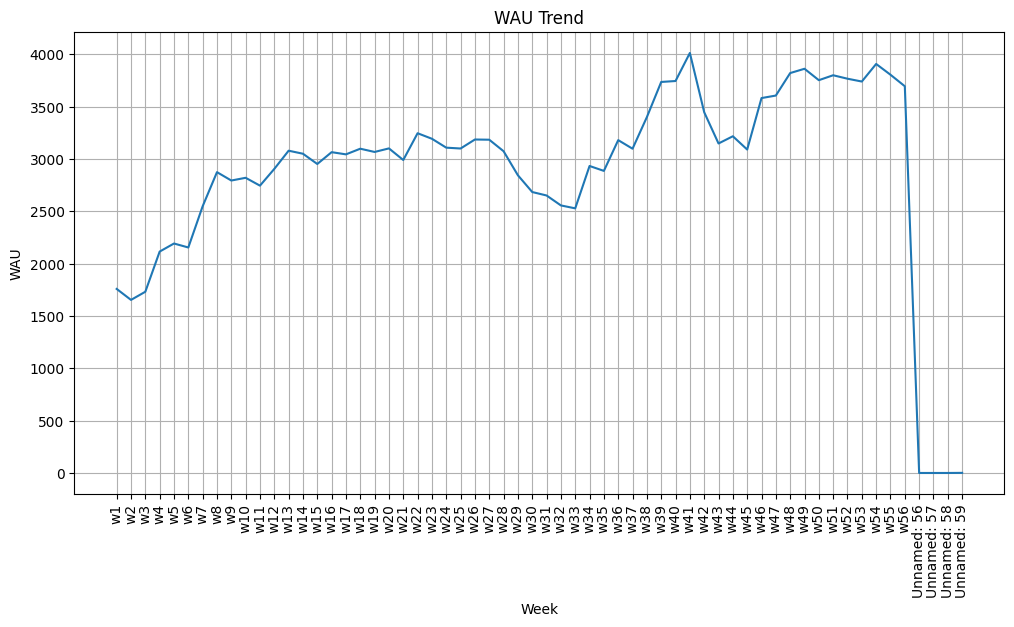

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    growth_df['Week'],
    growth_df['WAU']
)

plt.title("WAU Trend")

plt.xlabel("Week")
plt.ylabel("WAU")

plt.xticks(rotation=90)

plt.grid(True)

plt.show()

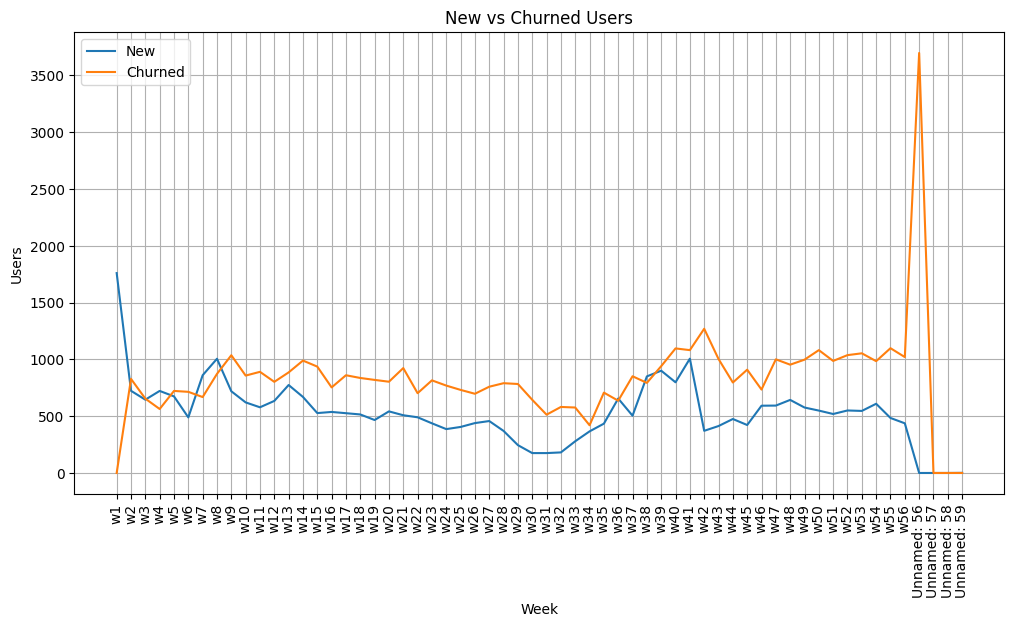

In [26]:
plt.figure(figsize=(12,6))

plt.plot(growth_df['Week'], growth_df['New'], label='New')

plt.plot(growth_df['Week'], growth_df['Churned'], label='Churned')

plt.title("New vs Churned Users")

plt.xlabel("Week")
plt.ylabel("Users")

plt.xticks(rotation=90)

plt.legend()

plt.grid(True)

plt.show()

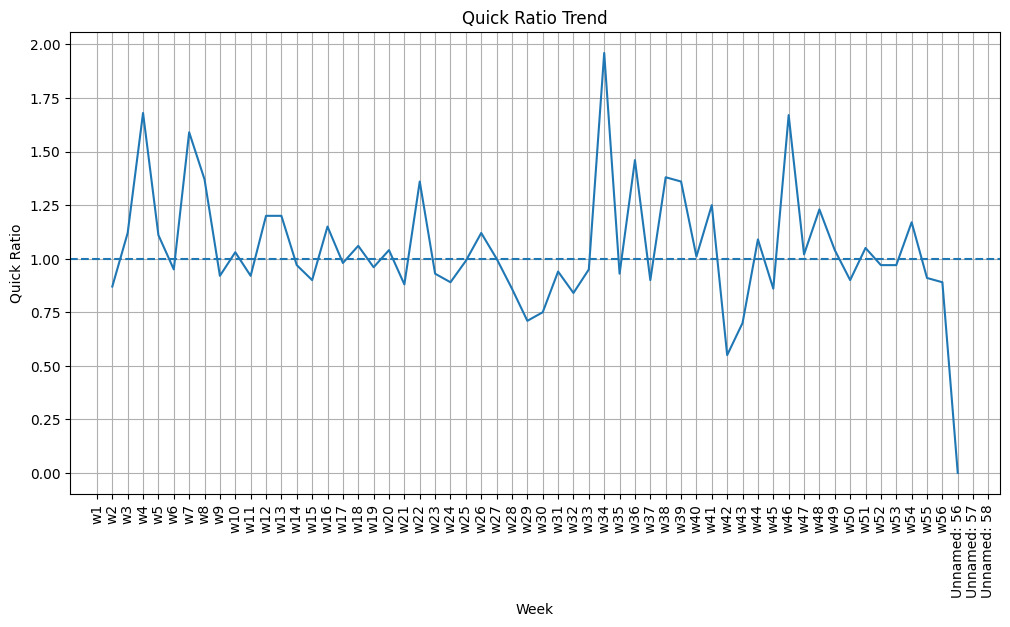

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    growth_df['Week'],
    growth_df['Quick_Ratio']
)

plt.axhline(
    y=1,
    linestyle='--'
)

plt.title("Quick Ratio Trend")

plt.xlabel("Week")
plt.ylabel("Quick Ratio")

plt.xticks(rotation=90)

plt.grid(True)

plt.show()

In [21]:
print("Starting WAU:",
      growth_df.iloc[0]['WAU'])

print("Ending WAU:",
      growth_df.iloc[-1]['WAU'])

avg_qr = growth_df['Quick_Ratio'].mean()

print("Average Quick Ratio:",
      round(avg_qr,2))

if avg_qr > 1:
    print("Healthy Growth")
else:
    print("Weak Growth")

Starting WAU: 1759
Ending WAU: 1
Average Quick Ratio: 1.04
Healthy Growth
